In [6]:
import logging
import time
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import emcee

In [8]:
logger = logging.getLogger("pymc")
logger.setLevel(logging.ERROR)

# -----------------------------
# 1. PyMC sampling
# -----------------------------
with pm.Model() as model:
    pm.Normal("x", shape=50)

    # Compile the model once
    pm.sample(tune=1, draws=1, chains=1, progressbar=False)

    # Time PyMC sampling
    start = time.time()
    pymc_trace = pm.sample(
        tune=1000,
        draws=5000,
        chains=2,
        cores=1,
        progressbar=False,
        return_inferencedata=True,
    )
    pymc_time = time.time() - start

    pymc_per_eff = pymc_time / np.mean(az.summary(pymc_trace)["ess_bulk"])


# -----------------------------
# 2. Build a PyTensor logp function for emcee
# -----------------------------

free_rvs = model.free_RVs

theta = pt.vector("theta")

# Map theta → model variables
replacements = {}
idx = 0
for rv in free_rvs:
    size = rv.eval().size
    replacements[rv] = theta[idx: idx + size].reshape(rv.eval().shape)
    idx += size

# Build the logp expression correctly for PyMC 5
logp_terms = [pm.logp(rv, replacements[rv]) for rv in free_rvs]
logp_expr = pt.sum(logp_terms)

# Compile to a callable function
logp_fn = pytensor.function([theta], logp_expr)

def logp(theta_val):
    return logp_fn(theta_val)


# -----------------------------
# 3. Run emcee
# -----------------------------
ndim = sum(v.eval().size for v in free_rvs)
nwalkers = 124
init = np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, logp)

start = time.time()
state = sampler.run_mcmc(init, 1000)
sampler.reset()
sampler.run_mcmc(state, 5000)
emcee_time = time.time() - start

emcee_trace = az.from_emcee(sampler=sampler)
emcee_per_eff = emcee_time / np.mean(az.summary(emcee_trace)["ess_bulk"])

In [9]:
print(
    f"For PyMC, the runtime per effective sample is: {pymc_per_eff * 1e3:.2f} ms"
)
print(
    f"For emcee, the runtime per effective sample is: {emcee_per_eff * 1e3:.2f} ms"
)

For PyMC, the runtime per effective sample is: 0.05 ms
For emcee, the runtime per effective sample is: 7.21 ms


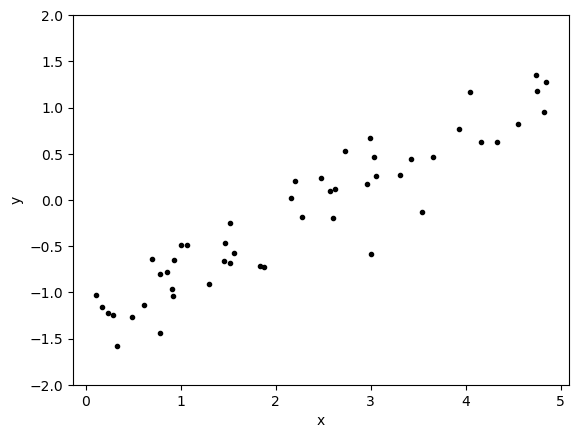

In [10]:
# Hello world (AKA fitting a line to data)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

true_m = 0.5
true_b = -1.3
true_logs = np.log(0.3)

x = np.sort(np.random.uniform(0, 5, 50))
y = true_b + true_m * x + np.exp(true_logs) * np.random.randn(len(x))

plt.plot(x, y, ".k")
plt.ylim(-2, 2)
plt.xlabel("x")
_ = plt.ylabel("y")

In [ ]:
import pymc as pm

with pm.Model() as model:
    # Define the priors on each parameter:
    m = pm.Uniform("m", lower=-5, upper=5)
    b = pm.Uniform("b", lower=-5, upper=5)
    logs = pm.Uniform("logs", lower=-5, upper=5)

    # Define the likelihood. A few comments:
    #  1. For mathematical operations like "exp", you can't use
    #     numpy. Instead, use the mathematical operations defined
    #     in "pm.math".
    #  2. To condition on data, you use the "observed" keyword
    #     argument to any distribution. In this case, we want to
    #     use the "Normal" distribution (look up the docs for
    #     this).
    pm.Normal("obs", mu=m * x + b, sigma=pm.math.exp(logs), observed=y)

    # This is how you will sample the model. Take a look at the
    # docs to see that other parameters that are available.
    trace = pm.sample(draws=1000, tune=1000, chains=2, cores=2)

In [11]:
import pymc as pm

with pm.Model() as model:
    # Define the priors on each parameter:
    m = pm.Uniform("m", lower=-5, upper=5)
    b = pm.Uniform("b", lower=-5, upper=5)
    logs = pm.Uniform("logs", lower=-5, upper=5)

    # Define the likelihood. A few comments:
    #  1. For mathematical operations like "exp", you can't use
    #     numpy. Instead, use the mathematical operations defined
    #     in "pm.math".
    #  2. To condition on data, you use the "observed" keyword
    #     argument to any distribution. In this case, we want to
    #     use the "Normal" distribution (look up the docs for
    #     this).
    pm.Normal("obs", mu=m * x + b, sigma=pm.math.exp(logs), observed=y)

    # This is how you will sample the model. Take a look at the
    # docs to see that other parameters that are available.
    trace = pm.sample(draws=1000, tune=1000, chains=2, cores=2)

Output()

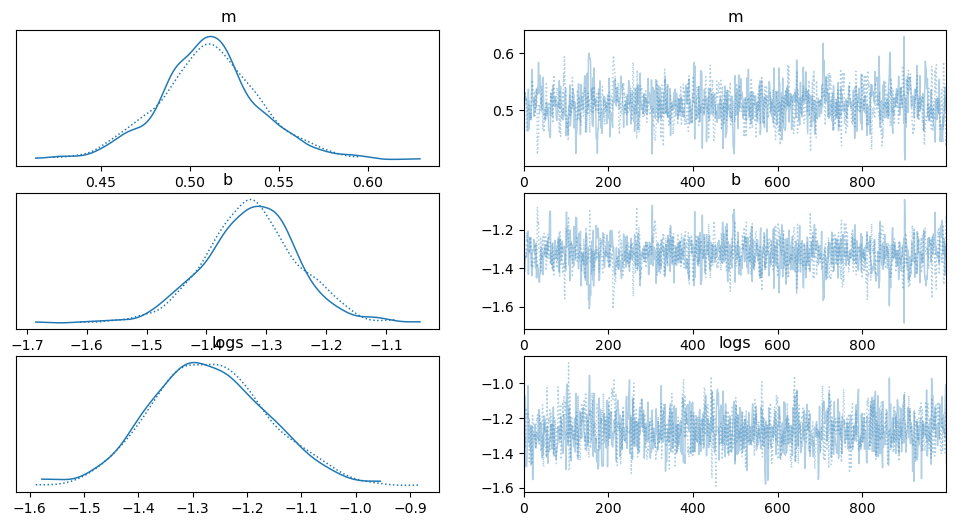

In [12]:
import arviz as az

_ = az.plot_trace(trace, var_names=["m", "b", "logs"])

In [13]:
az.summary(trace, var_names=["m", "b", "logs"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m,0.511,0.029,0.452,0.563,0.001,0.001,779.0,840.0,1.0
b,-1.326,0.078,-1.474,-1.183,0.003,0.002,818.0,782.0,1.0
logs,-1.269,0.106,-1.462,-1.065,0.003,0.002,1011.0,917.0,1.0


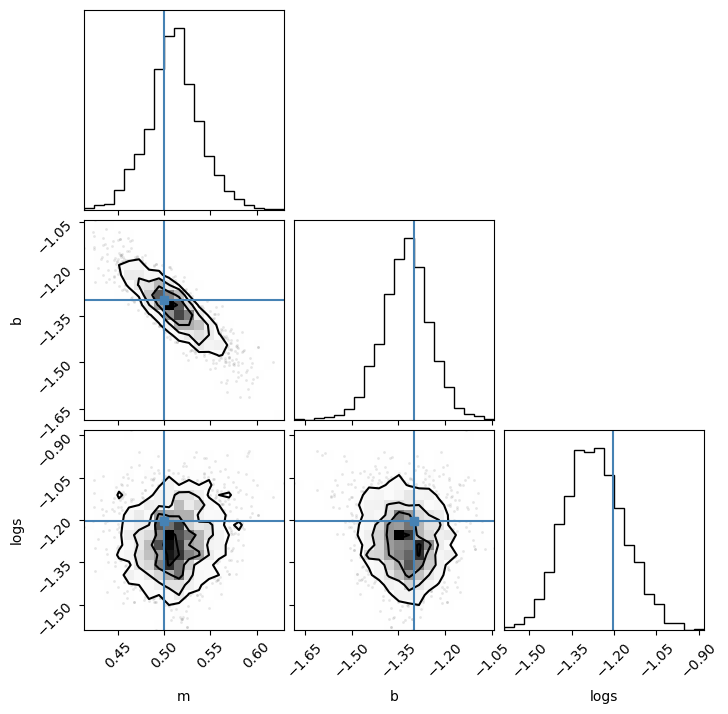

In [14]:
import corner

_ = corner.corner(
    trace,
    truths=dict(m=true_m, b=true_b, logs=true_logs),
)

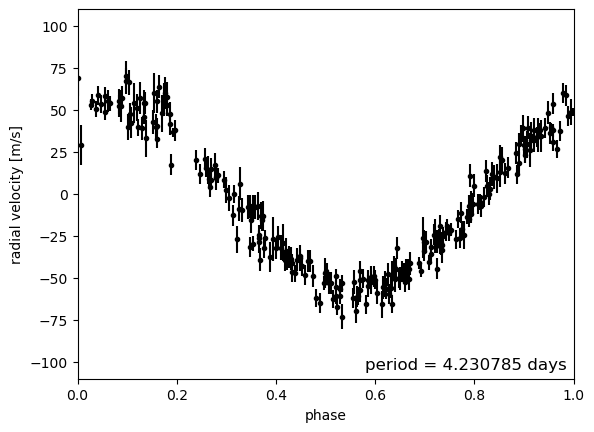

In [15]:
#A more realistic example: radial velocity exoplanets
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Download the dataset from the Exoplanet Archive:
url = "https://exoplanetarchive.ipac.caltech.edu/data/ExoData/0113/0113357/data/UID_0113357_RVC_001.tbl"
r = requests.get(url)
if r.status_code != requests.codes.ok:
    r.raise_for_status()
data = np.array(
    [
        l.split()
        for l in r.text.splitlines()
        if not l.startswith("\\") and not l.startswith("|")
    ],
    dtype=float,
)
t, rv, rv_err = data.T
t -= np.mean(t)

# Plot the observations "folded" on the published period:
# Butler et al. (2006) https://arxiv.org/abs/astro-ph/0607493
lit_period = 4.230785
plt.errorbar(
    (t % lit_period) / lit_period, rv, yerr=rv_err, fmt=".k", capsize=0
)
plt.xlim(0, 1)
plt.ylim(-110, 110)
plt.annotate(
    "period = {0:.6f} days".format(lit_period),
    xy=(1, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)
plt.ylabel("radial velocity [m/s]")
_ = plt.xlabel("phase")

In [16]:
import pytensor.tensor as pt
import exoplanet as xo

with pm.Model() as model:
    # Parameters
    logK = pm.Uniform(
        "logK",
        lower=0,
        upper=np.log(200),
        initval=np.log(0.5 * (np.max(rv) - np.min(rv))),
    )
    logP = pm.Uniform(
        "logP", lower=0, upper=np.log(10), initval=np.log(lit_period)
    )
    phi = pm.Uniform("phi", lower=0, upper=2 * np.pi, initval=0.1)

    # Parameterize the eccentricity using:
    #  h = sqrt(e) * sin(w)
    #  k = sqrt(e) * cos(w)
    h, k = xo.unit_disk("h", "k", initval=np.array([0.01, 0.01]))
    e = pm.Deterministic("e", h**2 + k**2)
    w = pm.Deterministic("w", pt.arctan2(k, h))

    rv0 = pm.Normal("rv0", mu=0.0, sigma=10.0, initval=0.0)
    rvtrend = pm.Normal("rvtrend", mu=0.0, sigma=10.0, initval=0.0)

    # Deterministic transformations
    n = 2 * np.pi * pt.exp(-logP)
    P = pm.Deterministic("P", pt.exp(logP))
    K = pm.Deterministic("K", pt.exp(logK))
    cosw = pt.cos(w)
    sinw = pt.sin(w)
    t0 = (phi + w) / n

    # The RV model
    bkg = pm.Deterministic("bkg", rv0 + rvtrend * t / 365.25)
    M = n * t - (phi + w)

    # This is the line that uses the custom Kepler solver
    f = xo.orbits.get_true_anomaly(M, e + pt.zeros_like(M))
    rvmodel = pm.Deterministic(
        "rvmodel", bkg + K * (cosw * (pt.cos(f) + e) - sinw * pt.sin(f))
    )

    # Condition on the observations
    pm.Normal("obs", mu=rvmodel, sigma=rv_err, observed=rv)

    # Compute the phased RV signal
    phase = np.linspace(0, 1, 500)
    M_pred = 2 * np.pi * phase - (phi + w)
    f_pred = xo.orbits.get_true_anomaly(M_pred, e + pt.zeros_like(M_pred))
    rvphase = pm.Deterministic(
        "rvphase", K * (cosw * (pt.cos(f_pred) + e) - sinw * pt.sin(f_pred))
    )

In [17]:
with model:
    map_params = pm.find_MAP()

Output()

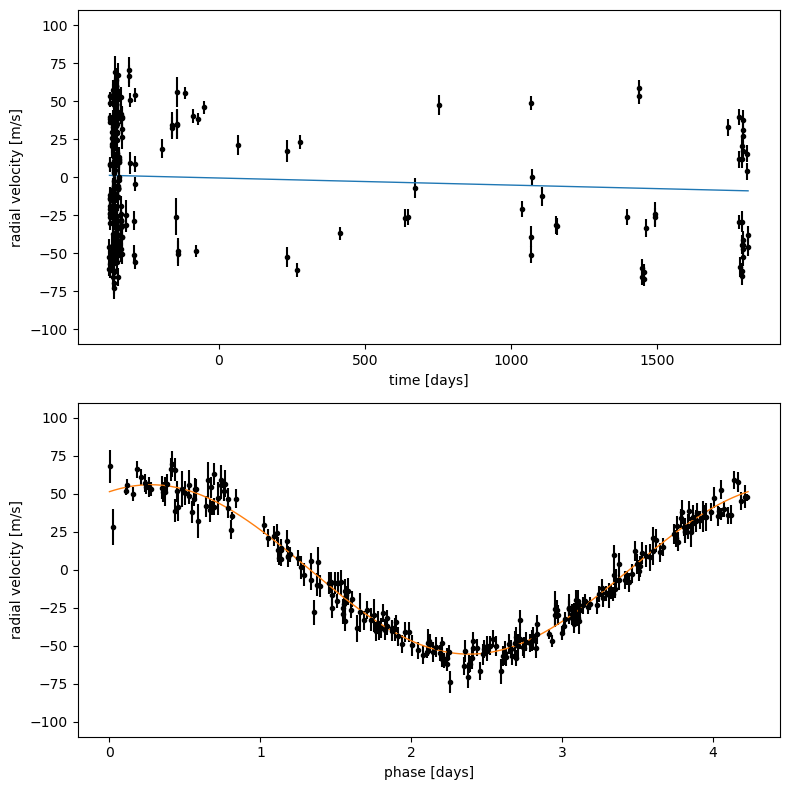

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k")
ax.plot(t, map_params["bkg"], color="C0", lw=1)
ax.set_ylim(-110, 110)
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("time [days]")

ax = axes[1]
ax.errorbar(t % period, rv - map_params["bkg"], yerr=rv_err, fmt=".k")
ax.plot(phase * period, map_params["rvphase"], color="C1", lw=1)
ax.set_ylim(-110, 110)
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("phase [days]")

plt.tight_layout()

In [19]:
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        initvals=map_params,
        chains=2,
        cores=2,
        target_accept=0.95,
        init="adapt_full",
    )

/opt/anaconda3/envs/exo/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")


Output()

In [20]:
az.summary(
    trace,
    var_names=["logK", "logP", "phi", "e", "w", "rv0", "rvtrend"],
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
logK,4.019,0.009,4.002,4.036,0.000,0.000,2307.0,1548.0,1.0
logP,1.442,0.000,1.442,1.442,0.000,0.000,2504.0,1616.0,1.0
phi,0.397,0.010,0.379,0.415,0.000,0.000,2264.0,1417.0,1.0
e,0.010,0.007,0.000,0.024,0.000,0.000,1883.0,1820.0,1.0
w,0.591,1.313,-2.212,2.969,0.031,0.026,1886.0,1730.0,1.0
rv0,-1.824,0.382,-2.545,-1.105,0.008,0.009,2366.0,1425.0,1.0
rvtrend,-1.586,0.187,-1.924,-1.204,0.004,0.005,2351.0,1398.0,1.0


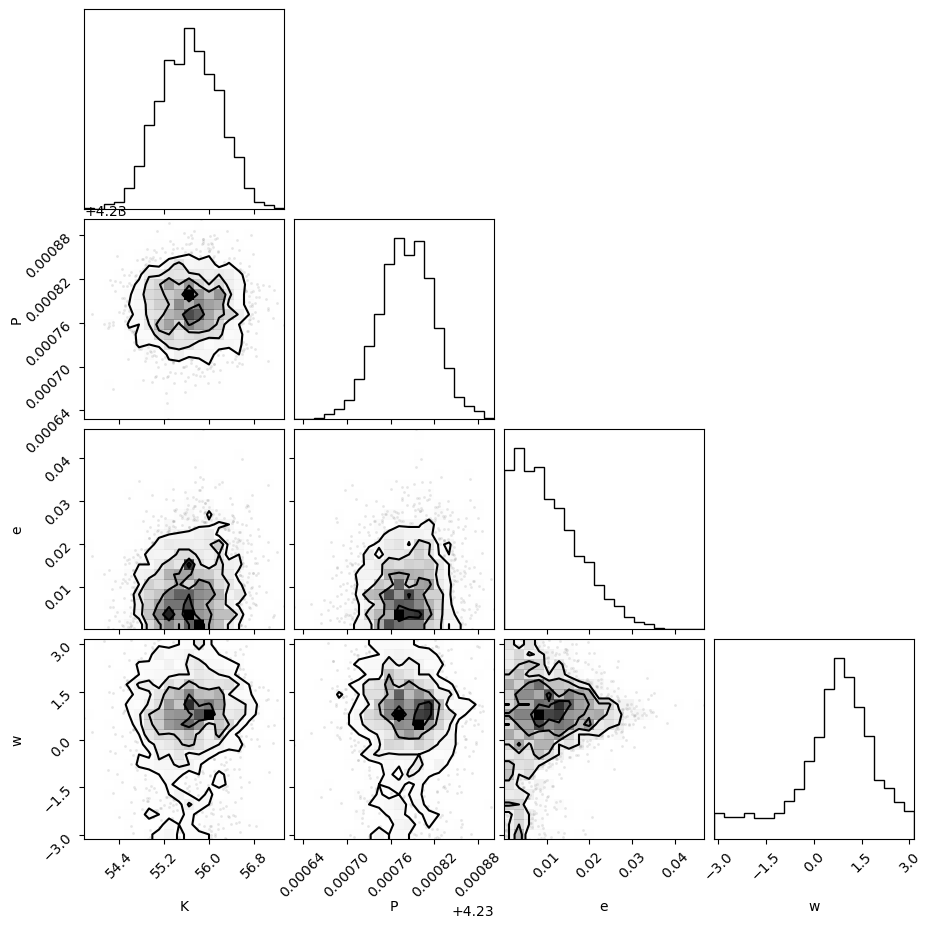

In [21]:
_ = corner.corner(trace, var_names=["K", "P", "e", "w"])

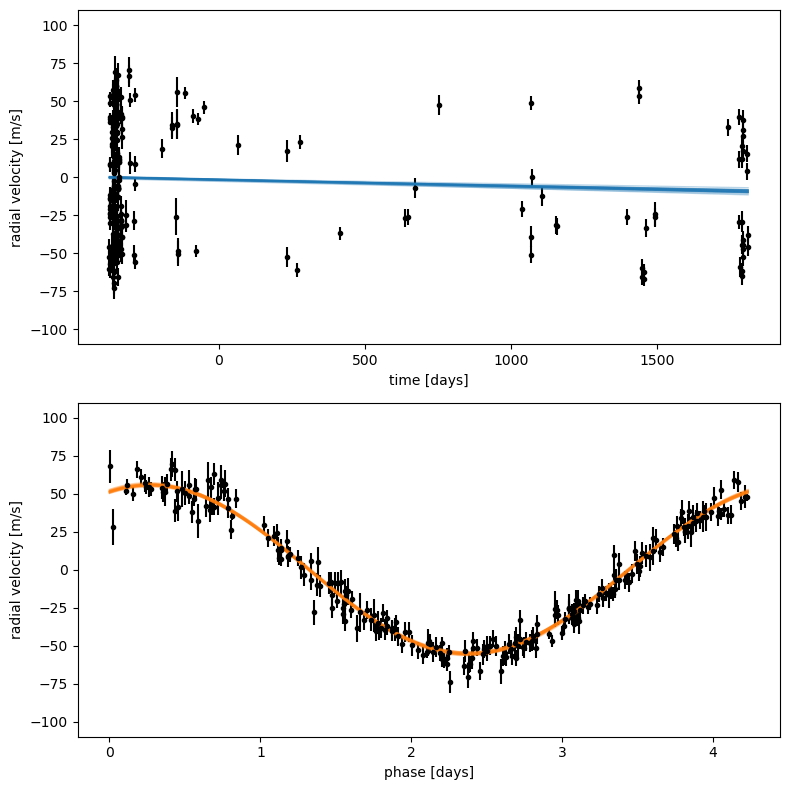

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k")
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("time [days]")

ax = axes[1]
ax.errorbar(t % period, rv - map_params["bkg"], yerr=rv_err, fmt=".k")
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("phase [days]")

bkg = trace.posterior["bkg"].values
rvphase = trace.posterior["rvphase"].values

for ind in np.random.randint(np.prod(bkg.shape[:2]), size=25):
    i = np.unravel_index(ind, bkg.shape[:2])
    axes[0].plot(t, bkg[i], color="C0", lw=1, alpha=0.3)
    axes[1].plot(phase * period, rvphase[i], color="C1", lw=1, alpha=0.3)

axes[0].set_ylim(-110, 110)
axes[1].set_ylim(-110, 110)

plt.tight_layout()

In [ ]:
# Data & models - Overview

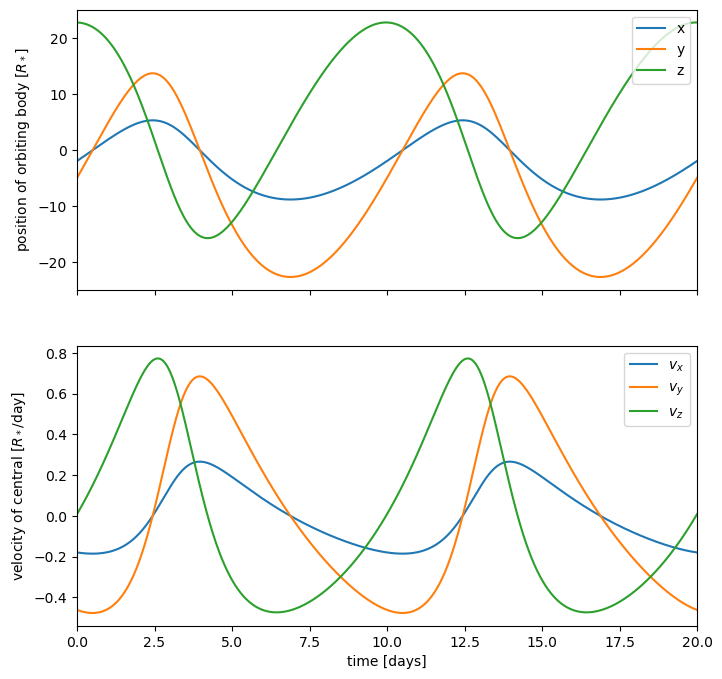

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import exoplanet as xo

# Define the orbit
orbit = xo.orbits.KeplerianOrbit(
     period=10.0,  # All times are in days
     t0=0.5,
     incl=0.5 * np.pi,  # All angles are in radians
     ecc=0.3,
     omega=-2.5,
     Omega=1.2,
     m_planet=0.05,  # All masses and distances are in Solar units
 )

#orbit = xo.orbits.KeplerianOrbit(
#    period=18.80171,  # All times are in days
#    t0=0.5,
#    incl=89.3 * np.pi,  # All angles are in radians
#    ecc=0.0,
#    omega=0,
#    Omega=0,
#    m_planet=2.88,  # All masses and distances are in Solar units
#)


# Get the position and velocity as a function of time
t = np.linspace(0, 20, 5000)
x, y, z = orbit.get_relative_position(t)
vx, vy, vz = orbit.get_star_velocity(t)

# Plot the coordinates
# Note the use of `.eval()` throughout since the coordinates are all
# PyTensor objects
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax = axes[0]
ax.plot(t, x.eval(), label="x")
ax.plot(t, y.eval(), label="y")
ax.plot(t, z.eval(), label="z")
ax.set_ylabel("position of orbiting body [$R_*$]")
ax.legend(fontsize=10, loc=1)

ax = axes[1]
ax.plot(t, vx.eval(), label="$v_x$")
ax.plot(t, vy.eval(), label="$v_y$")
ax.plot(t, vz.eval(), label="$v_z$")
ax.set_xlim(t.min(), t.max())
ax.set_xlabel("time [days]")
ax.set_ylabel("velocity of central [$R_*$/day]")
_ = ax.legend(fontsize=10, loc=1)

Output()

Output()

Initializing NUTS using adapt_full...
/opt/anaconda3/envs/exo/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_period, log_semiamp, ecc, __plus_angle1, __plus_angle2, __minus_angle1, __minus_angle2, log_jitter, zero_point]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_period,2.302,0.004,2.294,2.309,0.000,0.000,2278.0,1485.0,1.0
log_semiamp,1.625,0.032,1.567,1.687,0.001,0.001,2109.0,1327.0,1.0
log_jitter,-3.091,4.998,-12.003,6.462,0.096,0.116,2719.0,1254.0,1.0
zero_point,-0.122,0.120,-0.345,0.103,0.002,0.003,2435.0,1347.0,1.0
ecc,0.049,0.030,0.000,0.097,0.001,0.001,772.0,390.0,1.0
period,9.991,0.039,9.919,10.065,0.001,0.001,2278.0,1485.0,1.0
semiamp,5.082,0.163,4.792,5.402,0.004,0.004,2109.0,1327.0,1.0
plus,-0.913,1.170,-3.036,1.088,0.045,0.046,763.0,533.0,1.0
minus,0.809,0.036,0.745,0.878,0.001,0.001,2427.0,1612.0,1.0
phi,-0.104,1.174,-2.218,1.929,0.045,0.046,763.0,533.0,1.0


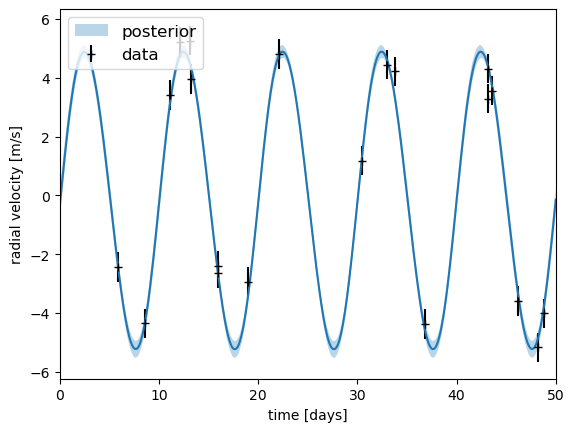

In [7]:
#Radial Velocities
import arviz as az
import pymc_ext as pmx
import pytensor.tensor as pt
import pymc as pm

# Create a dummy dataset
random = np.random.default_rng(1234)
t_plot = np.linspace(0, 50, 500)
t = np.sort(random.uniform(0, 50, 20))
rv_err = 0.5 + np.zeros_like(t)
rv_obs = 5.0 * np.sin(2 * np.pi * t / 10.0) + np.sqrt(
    0.05**2 + rv_err**2
) * random.normal(size=len(t))

with pm.Model():
    # Period, semi-amplitude, and eccentricity
    log_period = pm.Normal("log_period", mu=np.log(10.0), sigma=1.0)
    period = pm.Deterministic("period", pt.exp(log_period))
    log_semiamp = pm.Normal("log_semiamp", mu=np.log(5.0), sigma=2.0)
    semiamp = pm.Deterministic("semiamp", pt.exp(log_semiamp))
    ecc = pm.Uniform("ecc", lower=0, upper=0.5, initval=0.01)

    # At low eccentricity, omega and the phase of periastron (phi) are
    # correlated so it can be best to fit in (omega ± phi) / 2
    plus = pmx.angle("plus")
    minus = pmx.angle("minus")
    phi = pm.Deterministic("phi", plus + minus)
    omega = pm.Deterministic("omega", plus - minus)

    # For non-zero eccentricity, it can sometimes be better to use
    # sqrt(e)*sin(omega) and sqrt(e)*cos(omega) as your parameters:
    #
    #     h, k = xo.unit_disk("h", "k")
    #     ecc = pm.Deterministic("ecc", h**2 + k**2)
    #     omega = pm.Deterministic("omega", pt.arctan2(h, k))
    #     phi = xo.angle("phi")

    # Jitter & the system mean velocity offset
    log_jitter = pm.Normal("log_jitter", mu=np.log(0.05), sigma=5.0)
    zero_point = pm.Normal("zero_point", mu=0, sigma=10.0)

    # Then we define the orbit
    tperi = pm.Deterministic("tperi", period * phi / (2 * np.pi))
    orbit = xo.orbits.KeplerianOrbit(
        period=period, t_periastron=tperi, ecc=ecc, omega=omega
    )

    # And define the RV model
    rv_model = zero_point + orbit.get_radial_velocity(t, K=semiamp)

    # Finally add in the observation model
    err = pt.sqrt(rv_err**2 + pt.exp(2 * log_jitter))
    pm.Normal("obs", mu=rv_model, sigma=rv_err, observed=rv_obs)

    # We'll also track the model just for plotting purposes
    pm.Deterministic(
        "__rv_plot", zero_point + orbit.get_radial_velocity(t_plot, K=semiamp)
    )

    soln = pmx.optimize(vars=[plus, minus])
    soln = pmx.optimize(soln)
    trace = pm.sample(
        tune=1000,
        draws=1000,
        cores=2,
        chains=2,
        initvals=soln,
        target_accept=0.9,
        init="adapt_full",
    )

# Plot the results
rv_plot = trace.posterior["__rv_plot"].values
q16, q50, q84 = np.percentile(rv_plot, [16, 50, 84], axis=(0, 1))
plt.errorbar(t, rv_obs, yerr=rv_err, fmt="+k", label="data")
plt.plot(t_plot, q50)
plt.fill_between(t_plot, q16, q84, alpha=0.3, label="posterior")
plt.xlim(0, 50)
plt.legend(fontsize=12, loc=2)
plt.xlabel("time [days]")
plt.ylabel("radial velocity [m/s]")

az.summary(trace, var_names=["^(?!__).*"], filter_vars="regex")

Initializing NUTS using adapt_full...
/opt/anaconda3/envs/exo/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_period, log_a, ecc, tperi, __plus_angle1, __plus_angle2, __minus_angle1, __minus_angle2, cos_incl]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 91 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_period,9.198,0.470,8.734,9.792,0.327,0.021,3.0,12.0,1.98
log_a,-1.816,0.139,-1.927,-1.517,0.075,0.019,3.0,77.0,2.08
tperi,3501.869,0.465,3501.043,3503.010,0.124,0.185,20.0,20.0,1.91
ecc,0.364,0.206,0.159,0.608,0.144,0.006,3.0,12.0,1.98
cos_incl,-0.001,0.000,-0.001,-0.000,0.000,0.000,49.0,91.0,1.93
period,11003.385,4969.532,6212.316,17893.938,3395.703,350.229,3.0,12.0,1.98
a,0.164,0.025,0.145,0.219,0.013,0.004,3.0,77.0,2.08
plus,-0.419,0.007,-0.425,-0.404,0.004,0.001,3.0,61.0,2.04
minus,-0.325,0.012,-0.342,-0.314,0.008,0.001,3.0,22.0,1.90
Omega,-0.744,0.009,-0.765,-0.731,0.004,0.002,9.0,53.0,1.91


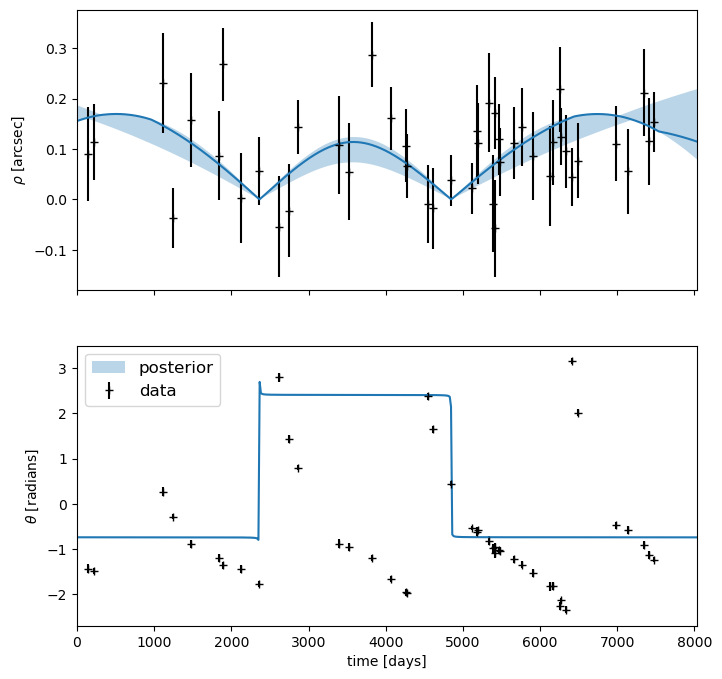

In [9]:
random = np.random.default_rng(5678)
t_plot = np.linspace(0, 22 * 365.25, 500)
t = np.sort(random.uniform(0.0, 22 * 365.25, 45))
rho_err = random.uniform(0.05, 0.1, len(t))
theta_err = random.uniform(0.05, 0.1, len(t))

with pm.Model():
    # Period, semi-major axis, eccentricity, and t0
    log_period = pm.Normal("log_period", mu=np.log(25.0 * 365.25), sigma=1.0)
    period = pm.Deterministic("period", pt.exp(log_period))
    log_a = pm.Normal("log_a", mu=np.log(0.3), sigma=2.0)
    a = pm.Deterministic("a", pt.exp(log_a))
    ecc = pm.Uniform("ecc", lower=0, upper=1)
    tperi = pm.Normal("tperi", mu=3500.0, sigma=1000.0)

    # For astrometric orbits, a good choice of parameterization can be
    # (Omega ± omega) / 2
    plus = pmx.angle("plus")
    minus = pmx.angle("minus")
    Omega = pm.Deterministic("Omega", plus + minus)
    omega = pm.Deterministic("omega", plus - minus)

    # We'll use a uniform prior on cos(incl)
    cos_incl = pm.Uniform("cos_incl", lower=-1.0, upper=1.0, initval=0.3)
    incl = pm.Deterministic("incl", pt.arccos(cos_incl))

    # Then we define the orbit
    orbit = xo.orbits.KeplerianOrbit(
        a=a,
        t_periastron=tperi,
        period=period,
        incl=incl,
        ecc=ecc,
        omega=omega,
        Omega=Omega,
    )

    # And define the RV model
    rho_model, theta_model = orbit.get_relative_angles(t)

    # ================================================== #
    # Simulate data from the model for testing           #
    # You should remove the following lines in your code #
    # ================================================== #
#    rho_obs, theta_obs = pmx.eval_in_model([rho_model, theta_model])
    rho_obs, theta_obs = pm.draw([rho_model, theta_model], draws=1, random_seed=5678)
    rho_obs = np.array(rho_obs)
    theta_obs = np.array(theta_obs)
    
    rho_obs += rho_err * random.normal(size=len(t))
    theta_obs += theta_err * random.normal(size=len(t))
    # =============== end simulated data =============== #

    # Define the observation model this is simple for rho:
    pm.Normal("rho_obs", mu=rho_model, sigma=rho_err, observed=rho_obs)

    # But we want to be cognizant of the fact that theta wraps so the following
    # is equivalent to
    #
    #   pm.Normal("obs_theta", mu=theta_model, observed=theta_obs, sigma=theta_err)
    #
    # but takes into account the wrapping
    theta_diff = pt.arctan2(
        pt.sin(theta_model - theta_obs), pt.cos(theta_model - theta_obs)
    )
    pm.Normal(
        "theta_obs",
        mu=theta_diff,
        sigma=theta_err,
        observed=np.zeros_like(theta_obs),
    )

    # We'll also track the model just for plotting purposes
    rho_plot, theta_plot = orbit.get_relative_angles(t_plot)
    pm.Deterministic("__rho_plot", rho_plot)
    pm.Deterministic("__theta_plot", theta_plot)

    trace = pm.sample(
        tune=1000,
        draws=1000,
        cores=2,
        chains=2,
        target_accept=0.95,
        init="adapt_full",
    )

# Plot the results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

q16, q50, q84 = np.percentile(
    trace.posterior["__rho_plot"].values, [16, 50, 84], axis=(0, 1)
)
ax1.errorbar(t, rho_obs, yerr=rho_err, fmt="+k", label="data")
ax1.plot(t_plot, q50)
ax1.fill_between(t_plot, q16, q84, alpha=0.3, label="posterior")
ax1.set_ylabel(r"$\rho$ [arcsec]")

q16, q50, q84 = np.percentile(
    trace.posterior["__theta_plot"].values, [16, 50, 84], axis=(0, 1)
)
ax2.errorbar(t, theta_obs, yerr=rho_err, fmt="+k", label="data")
ax2.plot(t_plot, q50)
ax2.fill_between(t_plot, q16, q84, alpha=0.3, label="posterior")
ax2.set_xlim(t_plot.min(), t_plot.max())
ax2.legend(fontsize=12, loc=2)
ax2.set_ylabel(r"$\theta$ [radians]")
ax2.set_xlabel("time [days]")

# Compute the convergence stats
az.summary(trace, var_names=["^(?!__).*"], filter_vars="regex")

In [15]:
#Light travel time delay

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import exoplanet as xo

orbit = xo.orbits.KeplerianOrbit(
    period=365.25,
    t0=0,
    incl=0.5 * np.pi,
    ecc=0.0,
    omega=0.0,
    Omega=0.0,
    m_planet=0.0,
    m_star=1.0,
    r_star=1.0,
)

t = np.linspace(-0.01, 0.01, 9999)
x, y, z = orbit.get_planet_position(t)
t0_obs1 = t[np.argmin(np.abs(x.eval()))]
print("{:.4f}".format(t0_obs1))

x, y, z = orbit.get_planet_position(t, light_delay=True)
t0_obs2 = t[np.argmin(np.abs(x.eval()))]
print("{:.4f}".format(t0_obs2))

print("{:.2f}".format((t0_obs2 * u.day).to(u.minute)))

0.0000
-0.0058
-8.32 min


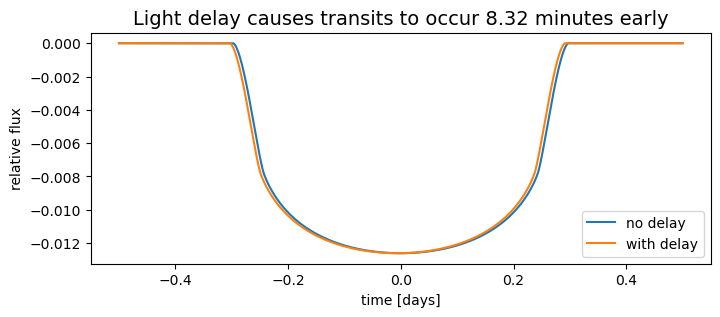

In [18]:
#here’s a comparison between a transit light curve that includes light travel delay and one that doesnt’t:
# Region around transit
t = np.linspace(-0.5, 0.5, 100000)

# No light delay
light_curve1 = (
    xo.LimbDarkLightCurve(0.5, 0.25)
    .get_light_curve(orbit=orbit, r=0.1, t=t)
    .eval()
)

# With light delay
light_curve2 = (
    xo.LimbDarkLightCurve(0.5, 0.25)
    .get_light_curve(orbit=orbit, r=0.1, t=t, light_delay=True)
    .eval()
)

# Plot!
fig = plt.figure(figsize=(8, 3))
plt.plot(t, light_curve1, label="no delay")
plt.plot(t, light_curve2, label="with delay")
plt.xlabel("time [days]")
plt.ylabel("relative flux")
plt.legend(fontsize=10, loc="lower right")
_ = plt.title(
    "Light delay causes transits to occur 8.32 minutes early", fontsize=14
)

/opt/anaconda3/envs/exo/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


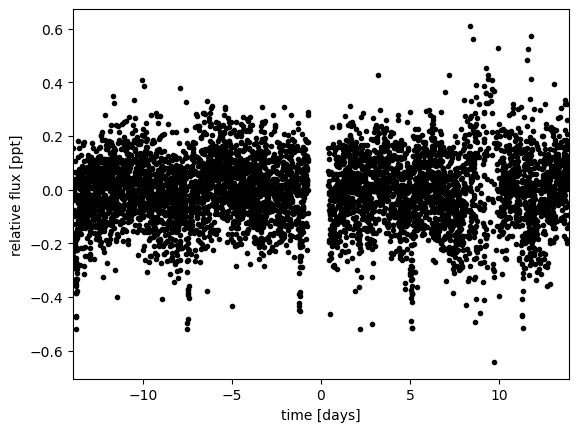

In [1]:
#Fitting TESS data
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
from astropy.io import fits

lc_file = lk.search_lightcurve(
    "TIC 261136679", sector=1, author="SPOC"
).download(quality_bitmask="hardest", flux_column="pdcsap_flux")
lc = lc_file.remove_nans().normalize().remove_outliers()
time = lc.time.value
flux = lc.flux

# For the purposes of this example, we'll discard some of the data
m = (lc.quality == 0) & (
    np.random.default_rng(261136679).uniform(size=len(time)) < 0.3
)

with fits.open(lc_file.filename) as hdu:
    hdr = hdu[1].header

texp = hdr["FRAMETIM"] * hdr["NUM_FRM"]
texp /= 60.0 * 60.0 * 24.0

ref_time = 0.5 * (np.min(time) + np.max(time))
x = np.ascontiguousarray(time[m] - ref_time, dtype=np.float64)
y = np.ascontiguousarray(1e3 * (flux[m] - 1.0), dtype=np.float64)

plt.plot(x, y, ".k")
plt.xlabel("time [days]")
plt.ylabel("relative flux [ppt]")
_ = plt.xlim(x.min(), x.max())

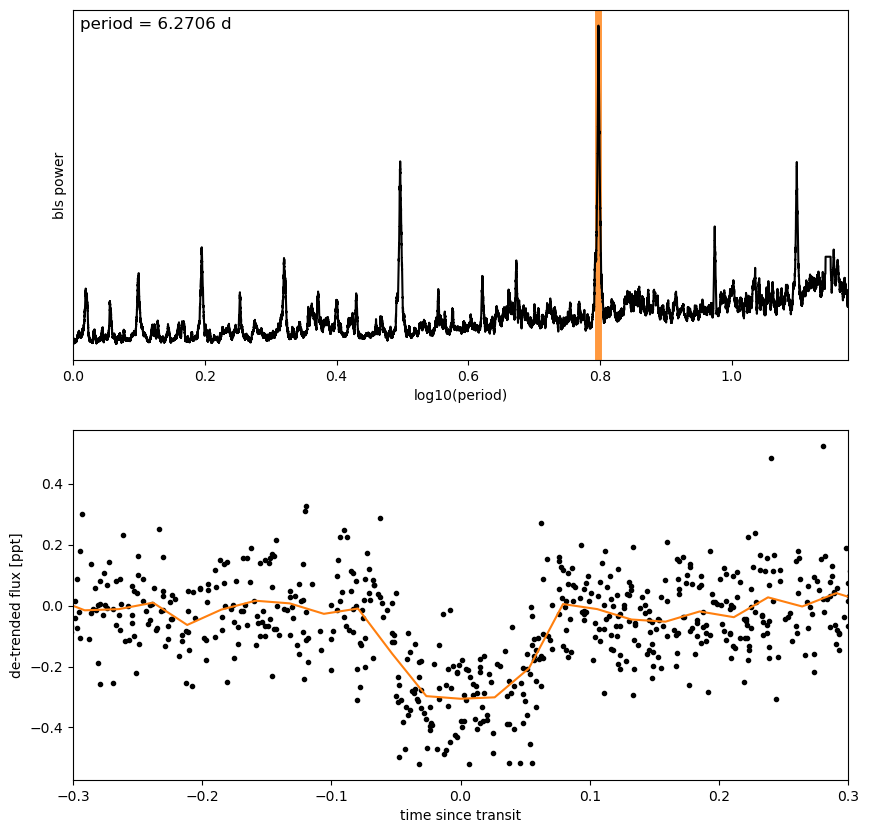

In [2]:
from astropy.timeseries import BoxLeastSquares

period_grid = np.exp(np.linspace(np.log(1), np.log(15), 50000))

bls = BoxLeastSquares(x, y)
bls_power = bls.power(period_grid, 0.1, oversample=20)

# Save the highest peak as the planet candidate
index = np.argmax(bls_power.power)
bls_period = bls_power.period[index]
bls_t0 = bls_power.transit_time[index]
bls_depth = bls_power.depth[index]
transit_mask = bls.transit_mask(x, bls_period, 0.2, bls_t0)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot the periodogram
ax = axes[0]
ax.axvline(np.log10(bls_period), color="C1", lw=5, alpha=0.8)
ax.plot(np.log10(bls_power.period), bls_power.power, "k")
ax.annotate(
    "period = {0:.4f} d".format(bls_period),
    (0, 1),
    xycoords="axes fraction",
    xytext=(5, -5),
    textcoords="offset points",
    va="top",
    ha="left",
    fontsize=12,
)
ax.set_ylabel("bls power")
ax.set_yticks([])
ax.set_xlim(np.log10(period_grid.min()), np.log10(period_grid.max()))
ax.set_xlabel("log10(period)")

# Plot the folded transit
ax = axes[1]
x_fold = (x - bls_t0 + 0.5 * bls_period) % bls_period - 0.5 * bls_period
m = np.abs(x_fold) < 0.4
ax.plot(x_fold[m], y[m], ".k")

# Overplot the phase binned light curve
bins = np.linspace(-0.41, 0.41, 32)
denom, _ = np.histogram(x_fold, bins)
num, _ = np.histogram(x_fold, bins, weights=y)
denom[num == 0] = 1.0
ax.plot(0.5 * (bins[1:] + bins[:-1]), num / denom, color="C1")

ax.set_xlim(-0.3, 0.3)
ax.set_ylabel("de-trended flux [ppt]")
_ = ax.set_xlabel("time since transit")